In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
import os
import xarray as xr
from netCDF4 import Dataset


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


In [3]:
groundtruth_enso_data = scipy.io.loadmat('../data/skill1.mat')
baseline_true, baseline_forecast = groundtruth_enso_data["sstn"], groundtruth_enso_data["sstv"]

In [5]:
baseline_true_enso = baseline_true[:,0]
baseline_true_enso.shape

(188,)

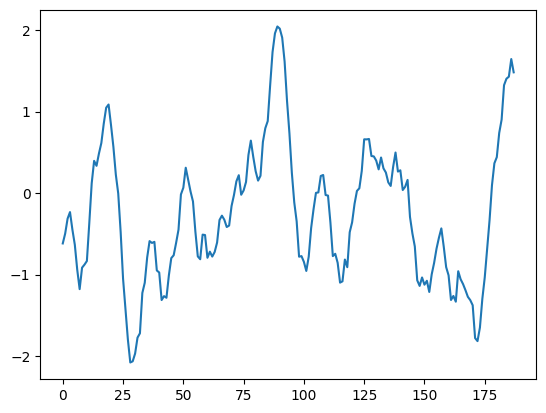

In [6]:
# this is the target provided by dmitri
plt.plot(baseline_true_enso)

In [7]:
xrdata = Dataset('../data/ersst2024-12.nc')

In [8]:
anom = xrdata.variables['anom'][:].squeeze()
anom = np.array(anom).transpose(0,2,1)
anom.shape

(900, 180, 45)

In [9]:
raw_data = scipy.io.loadmat('../data/raw_file.mat')
nino34_mat = scipy.io.loadmat('../data/nino34_mat.mat')
tdata = scipy.io.loadmat('../data/tdata.mat')


In [10]:
raw_data = raw_data['rawdata']
nino34_data = nino34_mat["nino34_data"][0][0]["region_data"]
indsst = scipy.io.loadmat('../data/indsst.mat')["indsst"]
tdata = tdata["tdata"]

In [11]:
print(f"nino34_data shape: {nino34_data.shape}")
print(f"raw_data shape: {raw_data.shape}")
print(f"indsst shape: {indsst.shape}")
print(f"tdata shape: {tdata.shape}")


nino34_data shape: (900, 180, 45)
raw_data shape: (900, 8100)
indsst shape: (180, 45)
tdata shape: (900, 8100)


In [12]:
import torch
raw_data_grid = torch.tensor(raw_data).view(-1, 180, 45)
tdata_grid = torch.tensor(tdata).view(-1, 180, 45)

In [13]:
raw_data_grid.shape

torch.Size([900, 180, 45])

In [8]:
first_grid_raw = raw_data_grid[0]
first_grid_nino34 = nino34_data[0]
first_grid_tdata = tdata_grid[0]


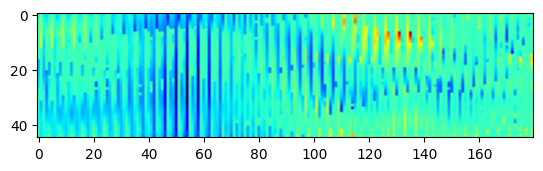

In [9]:
ims = plt.imshow(first_grid_raw.T, cmap='jet')

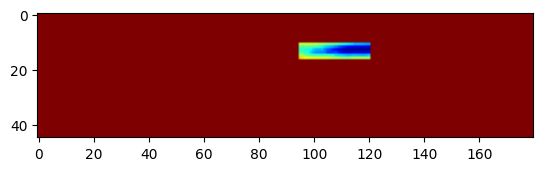

In [10]:
plt.imshow(first_grid_nino34.T, cmap='jet')

In [11]:
non_zero_mask = first_grid_nino34 != 0
non_zero_mask.shape

(180, 45)

In [12]:
anom[0].shape

(180, 45)

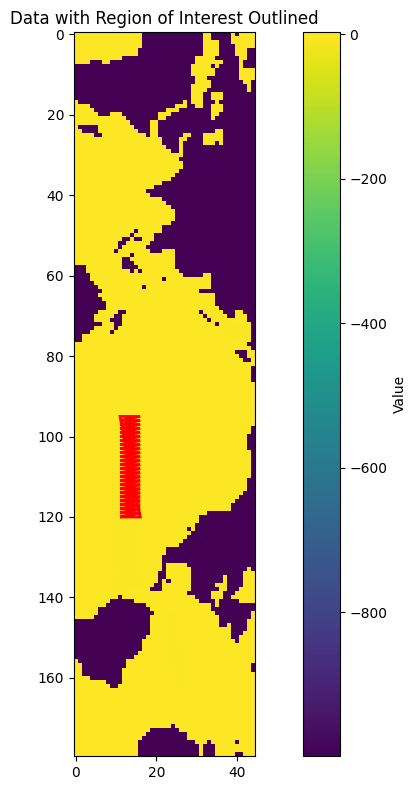

In [13]:
# Visualize
first_anom = anom[0]
plt.figure(figsize=(10, 8))

# Plot the data
plt.imshow(first_anom, cmap='viridis')
plt.colorbar(label='Value')

# Add contour around the mask
from matplotlib.patches import Polygon
y, x = np.where(non_zero_mask)
xy = np.column_stack([x, y])
poly = Polygon(xy, facecolor='none', edgecolor='red', linewidth=2)
plt.gca().add_patch(poly)

plt.title('Data with Region of Interest Outlined')
plt.tight_layout()

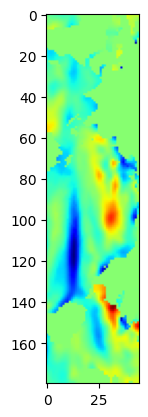

In [14]:
# replace the -999 with 0 
anom[anom == -999] = 0
ims = plt.imshow(anom[0], cmap='jet')

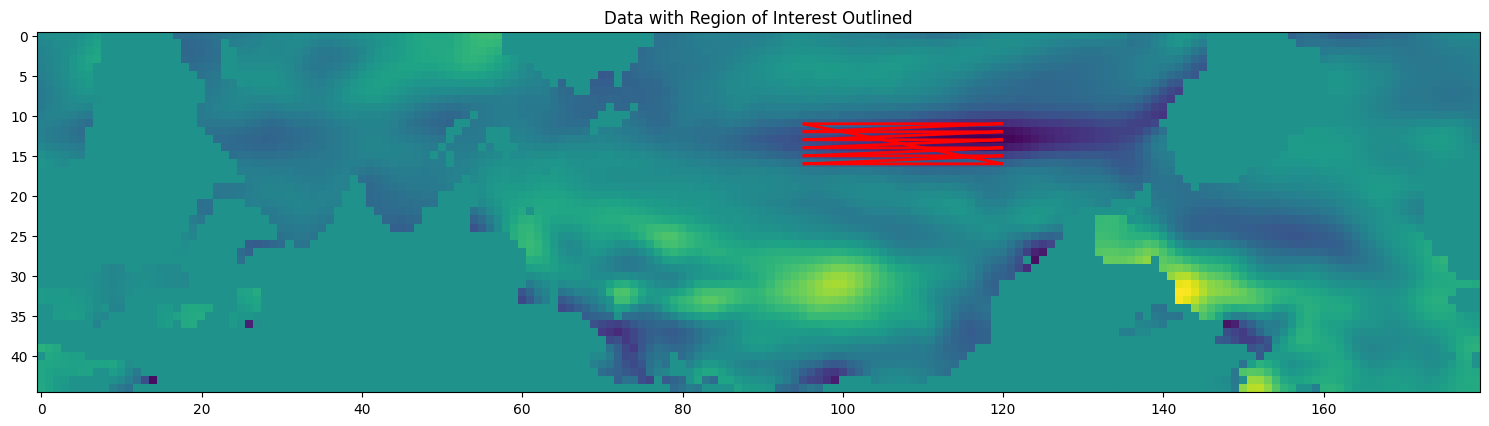

In [16]:
# Visualize
first_anom = anom[0]
plt.figure(figsize=(15, 8))

# Plot the data
plt.imshow(first_anom.T, cmap='viridis')

# Add contour around the mask
from matplotlib.patches import Polygon
y, x = np.where(non_zero_mask.T)
xy = np.column_stack([x, y])
poly = Polygon(xy, facecolor='none', edgecolor='red', linewidth=2)
plt.gca().add_patch(poly)

plt.title('Data with Region of Interest Outlined')
plt.tight_layout()
plt.savefig('first_anom.png')

## Create an Animation

In [17]:
import matplotlib.animation as animation
from matplotlib.patches import Rectangle

In [18]:
def create_ocean_animation(anom_data, mask=None, region_coords=None, fps=10, 
                          cmap='jet', output_path='ocean_animation.mp4',
                          enhance_contrast=False,
                          title_prefix='Ocean Data', vmin=None, vmax=None,
                          dpi=150, figsize=(12, 6)):
    """
    Create an animation of ocean data with highlighted region of interest.
    
    Args:
        anom_data (np.ndarray): Data array of shape (time_steps, height, width)
        mask (np.ndarray, optional): Binary mask array of shape (height, width)
        region_coords (tuple, optional): (min_y, max_y, min_x, max_x) for rectangular region
        fps (int): Frames per second in the output animation
        cmap (str): Colormap to use
        output_path (str): Path to save the output animation
        title_prefix (str): Prefix for the title of each frame
        vmin, vmax (float, optional): Color scale limits
        dpi (int): DPI for the output animation
        figsize (tuple): Figure size (width, height) in inches
    """
    # Set up the figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get global min/max if not provided
    if vmin is None:
        vmin = np.nanmin(anom_data)
    if vmax is None:
        vmax = np.nanmax(anom_data)
    if enhance_contrast:
        flat_data = anom_data.flatten()
        vmin = np.nanpercentile(flat_data, 2) if vmin is None else vmin
        vmax = np.nanpercentile(flat_data, 98) if vmax is None else vmax
        print(f"Enhanced contrast limits: vmin={vmin:.3f}, vmax={vmax:.3f}")
    
    # Initial frame
    im = ax.imshow(anom_data[0], cmap=cmap, vmin=vmin, vmax=vmax)
    # plt.colorbar(im, ax=ax, label='Value')
    
    # Title with frame number
    title = ax.set_title(f'{title_prefix} - Frame 0/{anom_data.shape[0]-1}')
    
    # If mask is provided, create a polygon for non-zero regions
    rect = None
    # if mask is not None:
    #     from matplotlib.patches import Polygon
    #     y, x = np.where(mask.T)
    #     xy = np.column_stack([x, y])
    #     poly = Polygon(xy, facecolor='none', edgecolor='red', linewidth=1)
    #     ax.add_patch(poly)
    
    # If region coordinates are provided, draw a rectangle
    print(region_coords)
    # if region_coords is not None:
    #     print("adding rectangle")
    #     min_y, max_y, min_x, max_x = region_coords
    #     width = max_x - min_x
    #     height = max_y - min_y
    #     rect = Rectangle((min_x, min_y), width, height, 
    #                      edgecolor='red', facecolor='none', linewidth=2)
    #     ax.add_patch(rect)
    if mask is not None:
        # Get bounds from mask
        min_y, max_y, min_x, max_x = get_region_from_mask(mask)
        width = max_x - min_x
        height = max_y - min_y
        # Draw a rectangle based on mask bounds rather than all points
        print(f"min_x = {min_x}, max_x = {max_x}, min_y = {min_y}, max_y = {max_y}")
        print(f"width = {width}, height = {height}")
        rect = Rectangle((min_x, min_y), width, height, 
                         edgecolor='red', facecolor='none', linewidth=3)
        ax.add_patch(rect)
    
    # Update function for animation
    def update(frame):
        im.set_array(anom_data[frame])
        title.set_text(f'{title_prefix} - Frame {frame}/{anom_data.shape[0]-1}')
        return im, title
    
    # Create the animation
    ani = animation.FuncAnimation(fig, update, frames=anom_data.shape[0], 
                                 blit=True, interval=1000/fps)
    
    # Save the animation
    print(f"Saving animation to {output_path}...")
    ani.save(output_path, dpi=dpi)
    plt.close()
    print(f"Animation saved successfully!")
    
    return output_path

def get_region_from_mask(mask):
    """
    Extract rectangular region bounds from a binary mask
    """
    # Find all True positions
    rows, cols = np.where(mask)
    
    # Find the bounding box
    min_row, max_row = np.min(rows), np.max(rows)
    min_col, max_col = np.min(cols), np.max(cols)
    
    return min_row, max_row+1, min_col, max_col+1  # +1 for inclusive bounds

def create_square_mask(height, width, min_y, max_y, min_x, max_x):
    """
    Create a square mask given coordinates
    """
    mask = np.zeros((height, width), dtype=bool)
    mask[min_y:max_y, min_x:max_x] = True
    return mask

In [14]:
region_coords = get_region_from_mask(non_zero_mask)

NameError: name 'get_region_from_mask' is not defined

In [20]:
# landmask: all the zeros 
seamask = anom[0] != 0
landmask = anom[0] == 0

In [21]:
landmask.sum()

np.int64(2653)

In [22]:
seamask.sum()

np.int64(5447)

In [23]:
seacoords = torch.nonzero(torch.tensor(seamask), as_tuple=False)
seacoords

tensor([[  0,   0],
        [  0,   1],
        [  0,   2],
        ...,
        [179,  42],
        [179,  43],
        [179,  44]])

In [24]:
import networkx as nx

G = nx.Graph()
rows, cols = seamask.shape

for coord in seacoords:
    x, y = coord.tolist()
    G.add_node((x, y))  # add node

    # Possible 4 neighbors: left, right, up, down (no diagonals)
    neighbors = [
        ((x - 1) % rows, y),  # up
        ((x + 1) % rows, y),  # down
        (x, (y - 1) % cols),  # left (wrap around)
        (x, (y + 1) % cols),  # right (wrap around)
    ]

    for nx_, ny_ in neighbors:
        if seamask[nx_, ny_]:
            G.add_edge((x, y), (nx_, ny_))

In [25]:
anom.shape

(900, 180, 45)

In [26]:
for x, y in G.nodes:
    G.nodes[(x, y)]['time_series'] = anom[:, x, y]
    G.nodes[(x, y)]['coord'] = (x, y)

In [27]:
def toroidal_dist(a, b, width):
    """ Euclidean distance with wrap in x. a,b are (y,x) """
    dy = a[0] - b[0]
    dx = abs(a[1] - b[1])
    dx = min(dx, width - dx)
    return np.hypot(dy, dx)


def build_wrapped_graph(mask):
    h, w = mask.shape
    ys, xs = np.nonzero(mask)
    points = list(zip(ys, xs))

    G = nx.Graph()
    G.add_nodes_from(points)

    # 1) add immediate 4‐neighbors w/ wrap
    for y, x in points:
        for dy, dx in [(-1,0),(1,0),(0,-1),(0,1)]:
            ny = y + dy
            nx_ = (x + dx) % w
            if 0 <= ny < h and mask[ny, nx_] == 1:
                G.add_edge((y,x), (ny, nx_))

    # 2) ensure connectivity via nearest‐component linking
    comps = list(nx.connected_components(G))
    while len(comps) > 1:
        best = None
        for i in range(len(comps)):
            for j in range(i+1, len(comps)):
                for pi in comps[i]:
                    for pj in comps[j]:
                        d = toroidal_dist(pi, pj, w)
                        if best is None or d < best[0]:
                            best = (d, i, j, pi, pj)
        _, i, j, pi, pj = best
        G.add_edge(pi, pj)
        comps = list(nx.connected_components(G))

    return G

# Usage:
graph = build_wrapped_graph(seamask)

def ensure_graph_connected(G, width):
    """
    Mutates G in-place so that it becomes connected.
    Adds the shortest toroidal-distance edge between components
    until there is only one connected component.
    """
    comps = list(nx.connected_components(G))
    # Keep going until only one component remains
    while len(comps) > 1:
        best = (float('inf'), None, None)  # (dist, u, v)
        # Compare every pair of components
        for i in range(len(comps)):
            for j in range(i+1, len(comps)):
                for u in comps[i]:
                    for v in comps[j]:
                        d = toroidal_dist(u, v, width)
                        if d < best[0]:
                            best = (d, u, v)
        _, u_best, v_best = best
        G.add_edge(u_best, v_best, bridge=True)
        comps = list(nx.connected_components(G))

# --- Example integration ---

# assume `mask` is your (180,45) array of 0/1
h, w = seamask.shape

# 2) ensure it’s fully connected
ensure_graph_connected(graph, w)



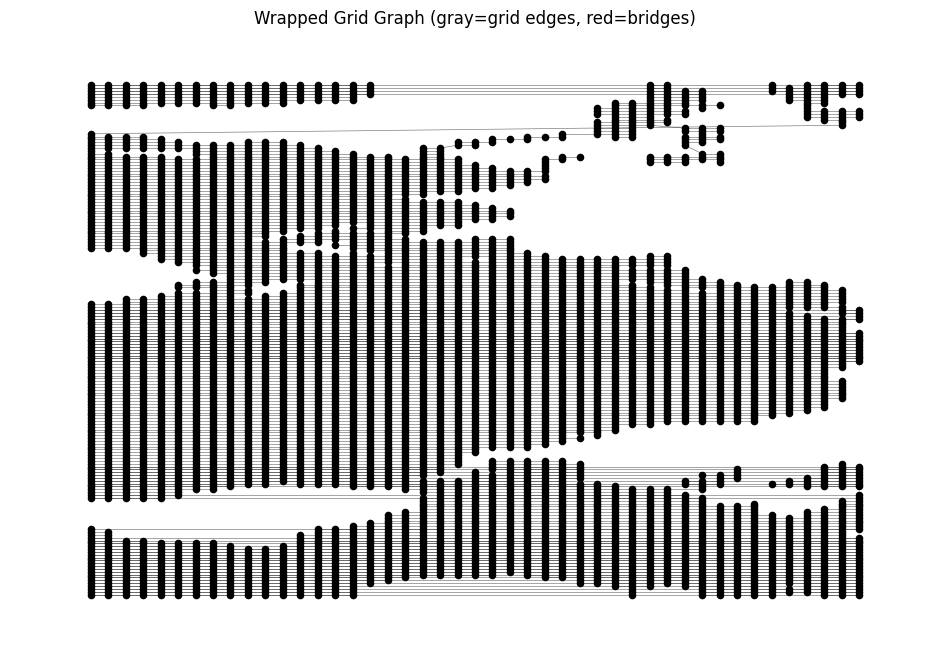

<Figure size 640x480 with 0 Axes>

In [28]:
G = graph
# 3) Prepare positions and edge lists for plotting
pos = { node: (node[1], node[0]) for node in G.nodes() }
grid_edges   = [(u,v) for u,v,d in G.edges(data=True) if not d.get('bridge', False)]
bridge_edges = [(u,v) for u,v,d in G.edges(data=True) if     d.get('bridge', False)]

# 4) Draw
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos, node_size=20, node_color='black')
nx.draw_networkx_edges(G, pos, edgelist=grid_edges,   width=0.5, alpha=0.5)
nx.draw_networkx_edges(G, pos, edgelist=bridge_edges, width=1.5, edge_color='red')
plt.gca().invert_yaxis()       # optional: have y=0 at top like array indexing
plt.axis('off')
plt.title("Wrapped Grid Graph (gray=grid edges, red=bridges)")
plt.show()
plt.savefig('wrapped_grid_graph.png')

In [29]:
non_zero_mask.shape

(180, 45)

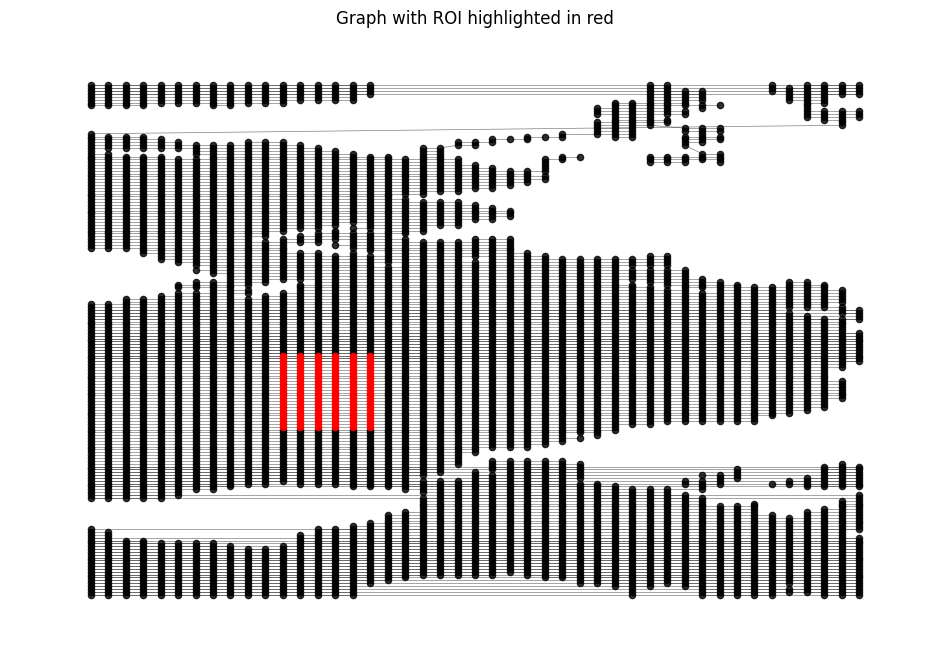

In [31]:
# 1) Find your ROI nodes
# roi_mask is your new (180,45) array of 0/1
roi_ys, roi_xs = np.nonzero(non_zero_mask)
roi_set = set(zip(roi_ys, roi_xs))

# Only keep those that actually exist in G:
roi_nodes = [n for n in G.nodes() if n in roi_set]

# 2) Split the nodes into “ROI” vs “the rest”
other_nodes = [n for n in G.nodes() if n not in roi_set]

# 3) Draw
plt.figure(figsize=(12,8))

# first draw the non-ROI nodes
nx.draw_networkx_nodes(
    G, pos,
    nodelist=other_nodes,
    node_size=20,
    node_color='black',
    alpha=0.8
)

# then draw the ROI nodes on top in red
nx.draw_networkx_nodes(
    G, pos,
    nodelist=roi_nodes,
    node_size=20,
    node_color='red',
    alpha=0.9
)

# edges as before
nx.draw_networkx_edges(G, pos, edgelist=grid_edges,   width=0.5, alpha=0.5)
nx.draw_networkx_edges(G, pos, edgelist=bridge_edges, width=1.5, edge_color='red')

plt.gca().invert_yaxis()
plt.axis('off')
plt.title("Graph with ROI highlighted in red")
plt.savefig('graph_with_roi_highlighted.png')

In [148]:
feature_set = anom

In [149]:
roi_nodes

[(np.int64(95), np.int64(11)),
 (np.int64(95), np.int64(12)),
 (np.int64(95), np.int64(13)),
 (np.int64(95), np.int64(14)),
 (np.int64(95), np.int64(15)),
 (np.int64(95), np.int64(16)),
 (np.int64(96), np.int64(11)),
 (np.int64(96), np.int64(12)),
 (np.int64(96), np.int64(13)),
 (np.int64(96), np.int64(14)),
 (np.int64(96), np.int64(15)),
 (np.int64(96), np.int64(16)),
 (np.int64(97), np.int64(11)),
 (np.int64(97), np.int64(12)),
 (np.int64(97), np.int64(13)),
 (np.int64(97), np.int64(14)),
 (np.int64(97), np.int64(15)),
 (np.int64(97), np.int64(16)),
 (np.int64(98), np.int64(11)),
 (np.int64(98), np.int64(12)),
 (np.int64(98), np.int64(13)),
 (np.int64(98), np.int64(14)),
 (np.int64(98), np.int64(15)),
 (np.int64(98), np.int64(16)),
 (np.int64(99), np.int64(11)),
 (np.int64(99), np.int64(12)),
 (np.int64(99), np.int64(13)),
 (np.int64(99), np.int64(14)),
 (np.int64(99), np.int64(15)),
 (np.int64(99), np.int64(16)),
 (np.int64(100), np.int64(11)),
 (np.int64(100), np.int64(12)),
 (np.i

In [150]:
T, H, W = feature_set.shape

# 1) get the list of node-coords in the same order as G.nodes()
nodes = list(G.nodes())        # [(y0,x0), (y1,x1), …]
ys, xs = zip(*nodes)           # two tuples of length N_nodes

# 2) extract into a 2D array of shape (N_nodes, T)
#    feature_set[:, ys, xs] -> shape (T, N_nodes), so transpose
node_features = feature_set[:, ys, xs].T   # now shape (N_nodes, T)

# node_features[i] is the time series for nodes[i]

# --- Optionally: store back onto G as a node attribute ---
# (so you can do G.nodes[(y,x)]['feature'])
feat_dict = { node: node_features[i] 
              for i, node in enumerate(nodes) }
nx.set_node_attributes(G, feat_dict, name='feature')

In [152]:
roi_coords = set(zip(*np.nonzero(non_zero_mask)))

# create a dict node → 0/1
is_roi_dict = { node: (1 if node in roi_coords else 0)
                for node in G.nodes() }

# attach it
nx.set_node_attributes(G, is_roi_dict, name="is_roi")

In [153]:
G

In [158]:
import torch
import numpy as np
import networkx as nx
from torch_geometric.data import Data

# — assume you already have —
# G : networkx.Graph where
#     each node is a (y,x) tuple
#     G.nodes[n]['feature'] is a length-T numpy array
#     G.nodes[n]['is_roi']   is 0 or 1
# nodes = list(G.nodes())

# 1) fix a node ordering and build a lookup
nodes = list(G.nodes())
node_idx = { n:i for i,n in enumerate(nodes) }
N = len(nodes)

# 2) build your node‐feature matrix X of shape [N, F]
#    here F = T + 1 (time series + ROI flag)
#    stack them in the same order as `nodes`
features = []
for n in nodes:
    ts = G.nodes[n]['feature']              # shape (T,)
    roi = np.array([G.nodes[n]['is_roi']])  # shape (1,)
    features.append(np.concatenate([ts, roi]))
X = torch.tensor(np.vstack(features), dtype=torch.float)  # [N, T+1]

# 3) build edge_index (2×E tensor)
#    for an undirected graph we list both directions
edge_list = []
for u, v in G.edges():
    ui, vi = node_idx[u], node_idx[v]
    edge_list.append([ui, vi])
    edge_list.append([vi, ui])
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()  # [2, E]

# 4) (optional) edge attributes: e.g. flag bridge vs grid‐edge
#    if you set G[u][v]['bridge']=True/False when building
edge_attr = []
for u, v in G.edges():
    flag = 1.0 if G[u][v].get('bridge', False) else 0.0
    # add for both directions
    edge_attr.append([flag])
    edge_attr.append([flag])
edge_attr = torch.tensor(edge_attr, dtype=torch.float)  # [E, 1]

# 5) pack into a PyG Data object
data = Data(x=X, edge_index=edge_index, edge_attr=edge_attr)

# 6) save it to disk
torch.save(data, 'wrapped_grid_graph.pt')


In [157]:
data

Data(x=[5447, 901], edge_index=[2, 20772], edge_attr=[20772, 1])

In [160]:
from torch_geometric.data import Data
import torch

data = torch.load('wrapped_grid_graph.pt', weights_only=False)
print(data)

Data(x=[5447, 901], edge_index=[2, 20772], edge_attr=[20772, 1])
